### CYBER_BULLYING DETECTION USING ENSEMBLE LEARNING

In [2]:
#REQUIRED LIBRARIES FOR THIS PROJECT
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC

from sklearn.ensemble import VotingClassifier, StackingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### LOADING DATASET

In [3]:
df = pd.read_csv("cyberbullying_tweets.csv")
print("dataset loaded")

dataset loaded


In [4]:
print(df.head())

                                          tweet_text cyberbullying_type
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


In [5]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(47692, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [7]:
df.columns

Index(['tweet_text', 'cyberbullying_type'], dtype='object')

### cleaning the test because to have the same case for easy training of text data

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['text'] = df['tweet_text'].apply(clean_text)

In [9]:
df['text']## after the cleaned text , everthing is is lower case

0        in other words katandandre your food was crapi...
1        why is aussietv so white mkr theblock imaceleb...
2        xochitlsuckkks a classy whore or more red velv...
3        jason gio meh p thanks for the heads up but no...
4        rudhoeenglish this is an isis account pretendi...
                               ...                        
47687    black ppl aren t expected to do anything depen...
47688    turner did not withhold his disappointment tur...
47689    i swear to god this dumb nigger bitch i have g...
47690    yea fuck you rt therealexel if youre a nigger ...
47691    bro u gotta chill rt chillshrammy dog fuck kp ...
Name: text, Length: 47692, dtype: object

### distibution of each class in the cyberbullying_type

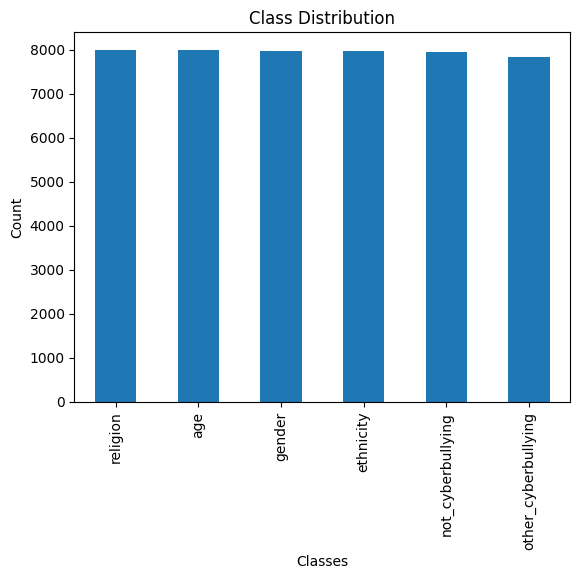

In [10]:
class_counts = df['cyberbullying_type'].value_counts()

# Plot class distribution
plt.figure()
class_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()


In [11]:
class_counts.sum()

np.int64(47692)

### training

In [12]:
X = df['text']
y = df['cyberbullying_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


### using two best models 

In [14]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
svc_model = LinearSVC(class_weight='balanced')

In [15]:
log_model.fit(X_train_tfidf, y_train)
svc_model.fit(X_train_tfidf, y_train)

log_pred = log_model.predict(X_test_tfidf)
svc_pred = svc_model.predict(X_test_tfidf)

print("sucessfully done")

sucessfully done


In [16]:

print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("SVC Accuracy:", accuracy_score(y_test, svc_pred))

Logistic Accuracy: 0.8337351923681727
SVC Accuracy: 0.826501729741063


### hard voting

In [17]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('svc', LinearSVC(class_weight='balanced'))
    ],
    voting='hard'
)

voting_clf.fit(X_train_tfidf, y_train)
voting_pred = voting_clf.predict(X_test_tfidf)

print("\nVoting Accuracy:", accuracy_score(y_test, voting_pred))


Voting Accuracy: 0.8277597232414299


### soft voting

In [18]:
svc_prob = SVC(kernel='linear', probability=True, class_weight='balanced')

soft_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('svc', svc_prob)
    ],
    voting='soft'
)
 
soft_voting.fit(X_train_tfidf, y_train)
soft_pred = soft_voting.predict(X_test_tfidf)

print("\nSoft Voting Accuracy:", accuracy_score(y_test, soft_pred))




Soft Voting Accuracy: 0.8380333368277597


In [19]:
stack_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ('svc', LinearSVC(class_weight='balanced'))
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

stack_model.fit(X_train_tfidf, y_train)
stack_pred = stack_model.predict(X_test_tfidf)

print("\nStacking Accuracy:", accuracy_score(y_test, stack_pred))




Stacking Accuracy: 0.8366705105356955


In [20]:
print(" Classification Report (Stacking)")
print(classification_report(y_test, stack_pred))

 Classification Report (Stacking)
                     precision    recall  f1-score   support

                age       0.97      0.98      0.97      1598
          ethnicity       0.98      0.97      0.97      1592
             gender       0.90      0.85      0.87      1595
  not_cyberbullying       0.62      0.55      0.58      1589
other_cyberbullying       0.61      0.73      0.66      1565
           religion       0.96      0.95      0.95      1600

           accuracy                           0.84      9539
          macro avg       0.84      0.84      0.84      9539
       weighted avg       0.84      0.84      0.84      9539



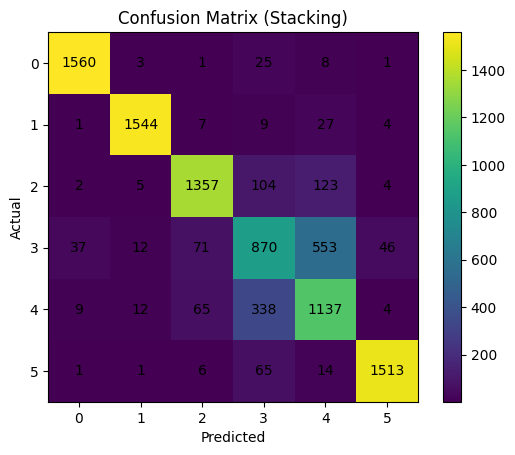

In [21]:
cm = confusion_matrix(y_test, stack_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Stacking)")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

 ### comapring the accuracy

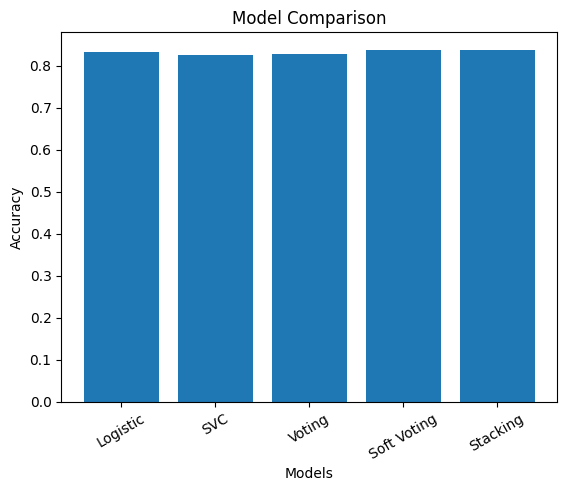

In [22]:
models = ['Logistic', 'SVC', 'Voting', 'Soft Voting', 'Stacking']
accuracies = [
    accuracy_score(y_test, log_pred),
    accuracy_score(y_test, svc_pred),
    accuracy_score(y_test, voting_pred),
    accuracy_score(y_test, soft_pred),
    accuracy_score(y_test, stack_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


### Final evaluation of every model 

In [23]:

models = {
    "Logistic Regression": log_model,
    "Linear SVC": svc_model,
    "Voting (Hard)": voting_clf,
    "Voting (Soft)": soft_voting,
    "Stacking": stack_model
}

predictions = {
    "Logistic Regression": log_pred,
    "Linear SVC": svc_pred,
    "Voting (Hard)": voting_pred,
    "Voting (Soft)": soft_pred,
    "Stacking": stack_pred
}


results = []# Store results

for name in models:
    acc = accuracy_score(y_test, predictions[name])
    
    report = classification_report(y_test, predictions[name], output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1 Score": report['weighted avg']['f1-score']
    })



In [24]:

results_df = pd.DataFrame(results)

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df)


=== MODEL PERFORMANCE COMPARISON ===
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.833735   0.838434  0.833735  0.835069
1           Linear SVC  0.826502   0.828553  0.826502  0.827239
2        Voting (Hard)  0.827760   0.828814  0.827760  0.828142
3        Voting (Soft)  0.838033   0.841225  0.838033  0.838999
4             Stacking  0.836671   0.840617  0.836671  0.837342


### USER INPUT PREDICTION

In [37]:
final_model = stack_model

def predict_text(text):
    text_cleaned = clean_text(text)
    text_vectorized = vectorizer.transform([text_cleaned])
    prediction = final_model.predict(text_vectorized)
    return prediction[0]



user_input = input("Enter a tweet: ") # here i am taking user input


result = predict_text(user_input) # results will be showed here 

print("Predicted Cyberbullying Type:", result)

Predicted Cyberbullying Type: gender


In [39]:
import pickle

# Save trained model
pickle.dump(stack_model, open("model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print("Files saved successfully")

Files saved successfully
